# Multi-Agent Deep Research System

This notebook combines all previous components into a single system with a final report generation step and a human in the loop to approve the research brief.

## Full Agent setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

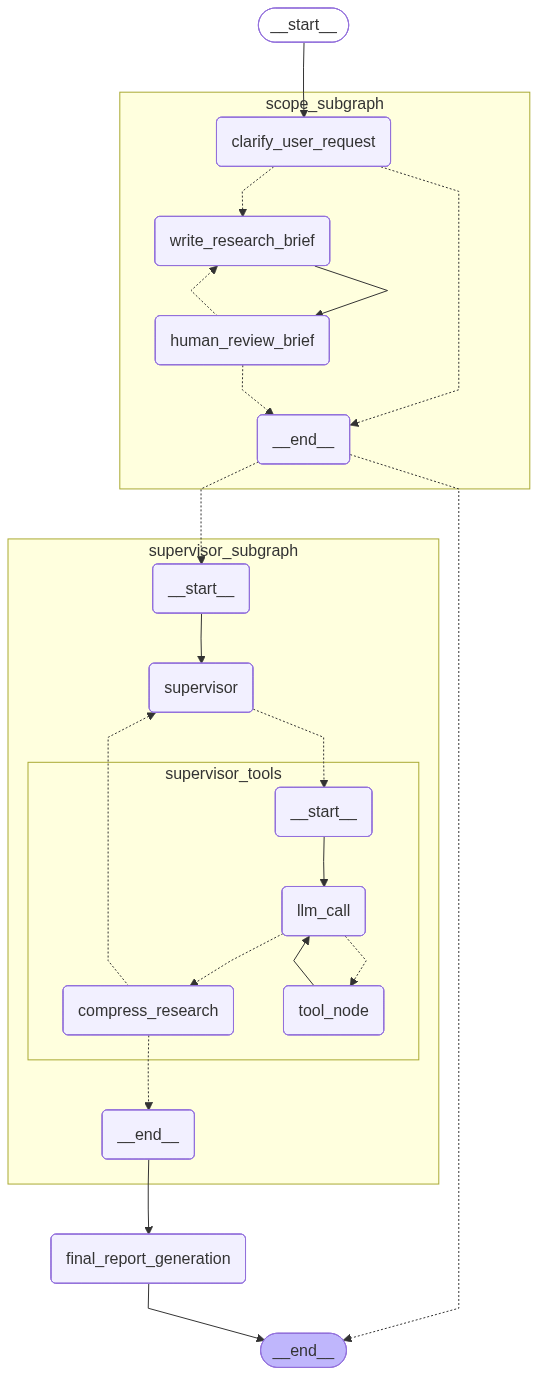

In [3]:
# %%writefile ./src/research_agent_full.py

"""
Full Multi-Agent Research System

This module integrates all components of the research system:
- User clarification and scoping (with human-in-the-loop brief review)
- Research brief generation
- Multi-agent research coordination
- Final report generation

The scoping phase (clarify -> brief -> human review -> revise loop) is composed
as a single shared-state subgraph, ``scope_research_agent``. The parent graph
inspects ``research_brief`` after the subgraph returns to decide whether to
proceed (approved brief) or end (clarification was needed and asked).

The system orchestrates the complete research workflow from initial user
input through final report delivery.
"""

from typing import Literal

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic

from src.utils import date_today_str
from src.agent_prompts import final_report_generation_prompt
from src.state_scope import AgentState, AgentInputState
from src.research_agent_scope import scope_research_agent
from src.multi_agent_supervisor import supervisor_agent

report_generation_model = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=32000, temperature=0)

############ FINAL REPORT GENERATION AGENT ############

async def generate_final_report(state: AgentState):
    """Synthesize all research findings into a comprehensive final report."""
    notes = state.get("notes", [])
    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=date_today_str(),
    )

    final_report = await report_generation_model.ainvoke([HumanMessage(content=final_report_prompt)])

    return {
        "final_report": final_report.content,
        "messages": ["Here is the final report: " + final_report.content],
    }


def route_after_scope(state: AgentState) -> Literal["supervisor_subgraph", "__end__"]:
    """
    scope_subgraph terminates two ways:
      - clarify_user_request asked a question -> no research_brief -> END parent.
      - human_review_brief approved the brief -> research_brief set -> proceed.
    """
    return "supervisor_subgraph" if state.get("research_brief") else END


######## FULL AGENT GRAPH CONSTRUCTION ########

deep_research_report_builder = StateGraph(AgentState, input_schema=AgentInputState)

deep_research_report_builder.add_node("scope_subgraph", scope_research_agent)
deep_research_report_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_research_report_builder.add_node("final_report_generation", generate_final_report)

deep_research_report_builder.add_edge(START, "scope_subgraph")
deep_research_report_builder.add_conditional_edges(
    "scope_subgraph",
    route_after_scope,
    ["supervisor_subgraph", END],
)
deep_research_report_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_research_report_builder.add_edge("final_report_generation", END)

from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
deep_researcher_agent = deep_research_report_builder.compile(checkpointer=memory)  # set again only to test in notebook
display(Image(deep_researcher_agent.get_graph(xray=True).draw_mermaid_png()))

## Testing

#### User request

In [4]:
from langchain_core.messages import HumanMessage
from src.utils import format_messages

test_thread = {
    "configurable": {
        "thread_id": "test_1",
        "recursion_limt": 50 # default langchain recursion limit is 25, but we want to allow more for this complex graph
        }
    }

response = await deep_researcher_agent.ainvoke(
    {
        "messages": [HumanMessage(content="I want to learn security for AI agents.")]
    },
    config=test_thread
)

format_messages(response["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to learn security for AI agents.                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Great topic! To tailor the research to your needs, could you clarify a few things?                              │
│                                                                                                                 │
│ 1. **Experience level** – Are you a beginner, intermediate, or advanced learner in AI/security?                 │
│ 2. **Focus area** – Which aspects of AI agent security are you most interested in? For example:                 │
│    - Threat modeling & attack surfaces (e.g., prompt injection, tool misuse)                                    │
│    - Defensive techniques & guardrails                                                                          │
│    - Secure agent architecture & design patterns                                                                │
│    - Compliance, governance & risk management                                                                   │
│    - All of the above                                                                                           │
│ 3. **Role/context** – Are you approaching this as a developer building AI agents, a security professional       │
│ auditing them, a researcher, or something else?                                                                 │
│ 4. **Scope** – Are you interested in a specific framework or platform (e.g., LangChain, AutoGPT, OpenAI Agents  │
│ SDK), or a general/framework-agnostic overview?                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Check LangSmith Tracing [here](https://smith.langchain.com/public/b3549006-c4af-4695-b7b1-fade8cd00840/r)

#### User Clarification

In [5]:
response = await deep_researcher_agent.ainvoke(
    {
        "messages": [HumanMessage(content="I want to learn all those areas at a production-level. I am a security professional, but I should be able to both audit them and be able to create agents.")]
    },
    config=test_thread
)

After this point, it would've generated a human review and waiting for approval or feedback. Check LangSmith Tracing [here](https://smith.langchain.com/public/b29cb00f-b123-4a80-a98c-d79847cc40a2/r)

In [14]:
flow_status = deep_researcher_agent.get_state(config=test_thread, subgraphs=True)
print("parent next:", flow_status.next)              # ('scope_subgraph',) --> execution still inside this

scope_task = flow_status.tasks[0]                    # subgraph task
print("subgraph name:", scope_task.name)             # 'scope_subgraph'
print("inner next:", scope_task.state.next)          # ('human_review_brief',)
print("interrupts:", scope_task.interrupts)          # interrupt payloads from human_review_brief

parent next: ('scope_subgraph',)
subgraph name: scope_subgraph
inner next: ('human_review_brief',)
interrupts: (Interrupt(value={'type': 'brief_review', 'research_brief': 'I am a security professional who wants to develop production-level expertise in AI agent security, covering both the ability to audit existing AI agents and to build secure ones from scratch. I need a comprehensive, framework-agnostic (but practically applicable) deep dive across all of the following areas:\n\n1. **Threat Modeling & Attack Surfaces** – Including but not limited to: prompt injection (direct and indirect), tool misuse and abuse, memory poisoning, agent hijacking, multi-agent trust boundary violations, supply chain attacks on agent components, and any other relevant attack vectors specific to AI agents as of 2025–2026.\n\n2. **Defensive Techniques & Guardrails** – Production-grade mitigations such as input/output validation, sandboxing tool execution, rate limiting, content filtering, anomaly detection,

In [13]:
print(flow_status.tasks[0].state.values["research_brief"])      # generated value for "research_brief"

I am a security professional who wants to develop production-level expertise in AI agent security, covering both the ability to audit existing AI agents and to build secure ones from scratch. I need a comprehensive, framework-agnostic (but practically applicable) deep dive across all of the following areas:

1. **Threat Modeling & Attack Surfaces** – Including but not limited to: prompt injection (direct and indirect), tool misuse and abuse, memory poisoning, agent hijacking, multi-agent trust boundary violations, supply chain attacks on agent components, and any other relevant attack vectors specific to AI agents as of 2025–2026.

2. **Defensive Techniques & Guardrails** – Production-grade mitigations such as input/output validation, sandboxing tool execution, rate limiting, content filtering, anomaly detection, privilege separation, and any emerging best practices for hardening AI agents against known attack classes.

3. **Secure Agent Architecture & Design Patterns** – Principles fo

#### Human Review

**Send a feedback**

In [ ]:
from langgraph.types import Command

# Reject + feedback -> loops back to write_research_brief in revise mode
deep_researcher_agent.invoke(
    Command(resume={
        "approved": False,
        "feedback": "you can skip the compliance standards and risk assessment sections, but keep governance and monitoring.",
    }),
    config=test_thread,
)

**Check current status**

In [16]:
flow_status = deep_researcher_agent.get_state(config=test_thread, subgraphs=True)
print("parent next:", flow_status.next)              # ('scope_subgraph',) --> execution still inside this

scope_task = flow_status.tasks[0]                    # subgraph task
print("subgraph name:", scope_task.name)             # 'scope_subgraph'
print("inner next:", scope_task.state.next)          # ('human_review_brief',)
print("interrupts:", scope_task.interrupts)          # interrupt payloads from human_review_brief

parent next: ('scope_subgraph',)
subgraph name: scope_subgraph
inner next: ('human_review_brief',)
interrupts: (Interrupt(value={'type': 'brief_review', 'research_brief': 'I am a security professional who wants to develop production-level expertise in AI agent security, covering both the ability to audit existing AI agents and to build secure ones from scratch. I need a comprehensive, framework-agnostic (but practically applicable) deep dive across all of the following areas:\n\n1. **Threat Modeling & Attack Surfaces** – Including but not limited to: prompt injection (direct and indirect), tool misuse and abuse, memory poisoning, agent hijacking, multi-agent trust boundary violations, supply chain attacks on agent components, and any other relevant attack vectors specific to AI agents as of 2025–2026.\n\n2. **Defensive Techniques & Guardrails** – Production-grade mitigations such as input/output validation, sandboxing tool execution, rate limiting, content filtering, anomaly detection,

**Check updated research_preview**

In [17]:
print(flow_status.tasks[0].state.values["research_brief"])      # generated value for "research_brief"

I am a security professional who wants to develop production-level expertise in AI agent security, covering both the ability to audit existing AI agents and to build secure ones from scratch. I need a comprehensive, framework-agnostic (but practically applicable) deep dive across all of the following areas:

1. **Threat Modeling & Attack Surfaces** – Including but not limited to: prompt injection (direct and indirect), tool misuse and abuse, memory poisoning, agent hijacking, multi-agent trust boundary violations, supply chain attacks on agent components, and any other relevant attack vectors specific to AI agents as of 2025–2026.

2. **Defensive Techniques & Guardrails** – Production-grade mitigations such as input/output validation, sandboxing tool execution, rate limiting, content filtering, anomaly detection, privilege separation, and any emerging best practices for hardening AI agents against known attack classes.

3. **Secure Agent Architecture & Design Patterns** – Principles fo

Check LangSmith Tracing [here](https://smith.langchain.com/public/129f6202-cdc3-4db5-b5a0-b7324cd47d2b/r)

**Provide approval**

- We've used `ainvoke` due to asynchronous components inside supervisor sub-graph.

In [19]:
# Approve -> proceeds to supervisor -> final report
response = await deep_researcher_agent.ainvoke(
    Command(resume={"approved": True}),
    config=test_thread,
)

#### Final Research Results

In [26]:
print(response["final_report"][:1000])

# AI Agent Security: A Comprehensive Production-Level Guide for Security Professionals

## Table of Contents

1. [Introduction & Threat Landscape Overview](#introduction)
2. [Threat Modeling & Attack Surfaces](#threat-modeling)
3. [Defensive Techniques & Guardrails](#defensive-techniques)
4. [Secure Agent Architecture & Design Patterns](#secure-architecture)
5. [Governance, Compliance & Monitoring](#governance)
6. [Frameworks Reference & Tooling](#frameworks)
7. [Conclusion & Prioritized Action Plan](#conclusion)

---

## Introduction & Threat Landscape Overview

AI agents — autonomous systems that combine large language models with tool access, memory, and multi-step reasoning — have moved from experimental prototypes to production infrastructure at extraordinary speed. According to Gartner data cited in recent security research, over 60% of large enterprises now deploy autonomous AI agents in production environments, up from just 15% in 2023. This adoption velocity has dramatically o

Check full agent's LangSmith Tracing [here](https://smith.langchain.com/public/87ae948a-20fb-4a28-80d8-3e4c81530fbb/r)